# House Price Prediction - Bengaluru

Full walkthrough of the project: load the data, explore it, clean the
quirks, engineer the features, train three regression models
(Linear, Ridge, Random Forest), evaluate them and save the artifacts
the web app uses.

The notebook finds the repository root automatically, so it can be
run from the repo root or from `notebooks/`:

```bash
jupyter-nbconvert --to notebook --execute --inplace notebooks/House_Price_Prediction.ipynb
```


In [1]:

import json
import os
import re
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option("display.max_columns", None)
print("imports ok")


imports ok


In [2]:

def _find_repo_root():
    for base in (os.getcwd(), os.path.dirname(os.getcwd())):
        if os.path.exists(os.path.join(base, "data", "Bengaluru_House_Data.csv")):
            return base
    raise FileNotFoundError("run the notebook from the repo root or notebooks/")

BASE = _find_repo_root()
DATA = os.path.join(BASE, "data", "Bengaluru_House_Data.csv")
MODELS = os.path.join(BASE, "models")
ARTIFACTS = os.path.join(BASE, "artifacts")
print("repo root:", BASE)


repo root: /home/user/HOUSE-PRICE-PREDICTION-USING-MACHINE-LEARNING-ALGORITHMS


## 1. The data

In [3]:

data = pd.read_csv(DATA)
print(f"shape: {data.shape}")
data.head(10)


shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [4]:

print(data.dtypes)
print()
data.isnull().sum()


area_type           str
availability        str
location            str
size                str
society             str
total_sqft          str
bath            float64
balcony         float64
price           float64
dtype: object



area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

A few things to notice before any modelling:

- `total_sqft` is **text**, not a number, and mixes square feet with other
  units ("34.46Sq. Meter", "1100Sq. Yards", "5Acres").
- `society` is missing in about 41% of the rows.
- `availability` mixes "Ready To Move" with dates such as "18-Dec".
- The price column has a long right tail (a few thousand-Lakh listings).


## 2. Exploration

In [5]:

def parse_sqft(value):
    """Turn a total_sqft entry into a float number of square feet."""
    if value is None or pd.isna(value):
        return np.nan
    text = str(value).strip().replace(",", "")
    if not text:
        return np.nan
    match = re.fullmatch(r"([\d.]+)\s*([- \u2013to]+)\s*([\d.]+)", text, flags=re.IGNORECASE)
    if match:
        first, second = float(match.group(1)), float(match.group(3))
        if first <= second:
            return (first + second) / 2
    try:
        number = float(text)
    except ValueError:
        unit_match = re.fullmatch(r"([\d.]+)\s*([A-Za-z. ]+)", text, flags=re.IGNORECASE)
        if not unit_match:
            return np.nan
        factor = SQFT_PER_UNIT.get(unit_match.group(2).strip().lower())
        if factor is None:
            return np.nan
        return float(unit_match.group(1)) * factor
    return number

SQFT_PER_UNIT = {
    "sq. meter": 10.7639, "sq meter": 10.7639, "sqm": 10.7639,
    "sq. yards": 1.19599, "sq yards": 1.19599, "sqyd": 1.19599,
    "perch": 272.25, "acres": 43560.0, "acre": 43560.0,
    "guntha": 1011.71, "ground": 10890.0,
}
print("helpers defined")


helpers defined


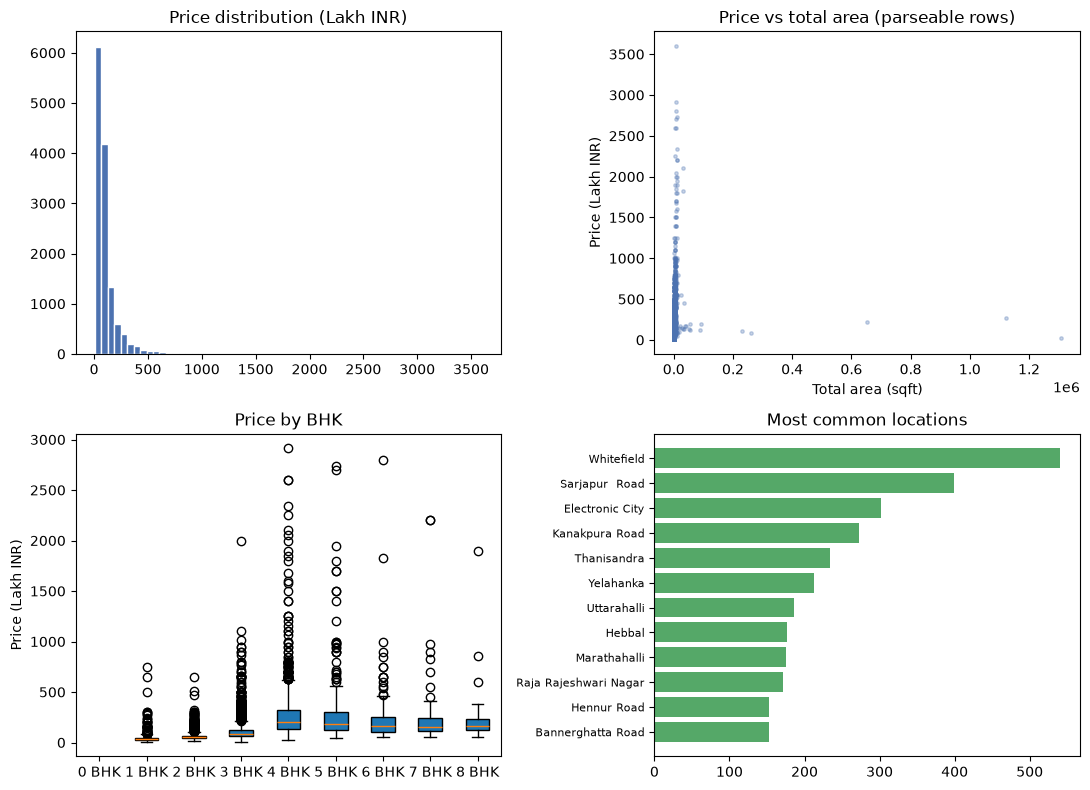

In [6]:

def _bhk_quick(s):
    """Quick bedroom count for the charts (full logic is in section 3)."""
    if pd.isna(s):
        return np.nan
    m = re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else np.nan


sqft = data["total_sqft"].map(parse_sqft)
bhk = data["size"].map(_bhk_quick).fillna(3).astype(int).clip(0, 14)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0][0].hist(data["price"], bins=60, color="#4c72b0", edgecolor="white")
axes[0][0].set_title("Price distribution (Lakh INR)")

axes[0][1].scatter(sqft, data["price"], s=6, alpha=0.3, color="#4c72b0")
axes[0][1].set_title("Price vs total area (parseable rows)")
axes[0][1].set_xlabel("Total area (sqft)")
axes[0][1].set_ylabel("Price (Lakh INR)")

axes[1][0].boxplot([data.loc[bhk == b, "price"] for b in range(0, 9)],
                   tick_labels=[f"{b} BHK" for b in range(0, 9)], patch_artist=True)
axes[1][0].set_title("Price by BHK")
axes[1][0].set_ylabel("Price (Lakh INR)")

counts = data["location"].value_counts().head(12)
axes[1][1].barh(range(len(counts)), counts.values, color="#55a868")
axes[1][1].set_yticks(range(len(counts)))
axes[1][1].set_yticklabels(counts.index, fontsize=8)
axes[1][1].invert_yaxis()
axes[1][1].set_title("Most common locations")

plt.tight_layout()
plt.show()


The scatter makes the price spread obvious: for the same size, prices vary
by a factor of 10 depending on location and society. That variation is
exactly what the location/society features have to capture.


## 3. Cleaning and feature engineering

In [7]:

def extract_bhk(size):
    """Bedroom count from labels like '2 BHK', '4 Bedroom', 'Studio'."""
    if size is None or pd.isna(size):
        return np.nan
    text = str(size)
    if re.search(r"\bstudio\b", text, flags=re.IGNORECASE):
        return 0
    if re.search(r"\brk\b", text, flags=re.IGNORECASE):
        return 1
    m = re.search(r"(\d+)", text)
    return int(m.group(1)) if m else np.nan


def parse_availability(value):
    """Completion year; 0 means ready to move ('18-Dec' -> 2018)."""
    if value is None or pd.isna(value):
        return 0
    text = str(value).strip()
    if re.fullmatch(r"\d{2}-[A-Za-z]{3}", text):
        return 2000 + int(text[:2])
    return 0

df = data.copy()
df["total_sqft"] = df["total_sqft"].map(parse_sqft)
df["bhk"] = df["size"].map(extract_bhk)
df["bath"] = pd.to_numeric(df["bath"], errors="coerce").fillna(0)
df["balcony"] = pd.to_numeric(df["balcony"], errors="coerce").fillna(0)
df["bhk"] = df["bhk"].fillna(df["bhk"].median()).astype(int)

sane = (
    df["total_sqft"].notna()
    & (df["total_sqft"] >= 100)
    & (df["total_sqft"] <= 10000)
    & (df["bath"] <= 12)
    & (df["bhk"] <= 14)
)
print(f"rows dropped: {int((~sane).sum())} ({(~sane).mean()*100:.1f}%)")
df = df[sane].copy()
df["total_sqft"] = df["total_sqft"].fillna(df["total_sqft"].median())

df["completion_year"] = df["availability"].map(parse_availability).astype(int)
df["location"] = df["location"].astype("string").str.strip().fillna("__MISSING__").astype(str)
df["society"] = df["society"].astype("string").str.strip().fillna("__MISSING__").astype(str)
df["area_type"] = df["area_type"].fillna("Other").astype(str)
print("shape after cleaning:", df.shape)
df.head(5)


rows dropped: 59 (0.4%)
shape after cleaning: (13261, 11)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,completion_year
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,2019
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,__MISSING__,1440.0,2.0,3.0,62.00,3,0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,__MISSING__,1200.0,2.0,1.0,51.00,2,0


In [8]:

print("ready to move:", (df["completion_year"] == 0).sum(),
      "| under construction:", (df["completion_year"] > 0).sum())
print()
df["completion_year"].value_counts().sort_index().tail(10)


ready to move: 10551 | under construction: 2710



completion_year
0       10551
2014        2
2015        7
2016       13
2017      130
2018     1669
2019      473
2020      183
2021      182
2022       51
Name: count, dtype: int64

- Rows with impossible measurements (11 sqft flats, 52,000 sqft houses,
  40 bathrooms) are removed.
- Areas in other units are converted to square feet; farm-scale listings
  (acres, perch) fall out of the 100-10,000 sqft window.
- Missing locations/societies become the `__MISSING__` category instead of
  0, so "no data" is never confused with a real name.


## 4. Split and encoding

In [9]:

FEATURES = ["total_sqft", "bath", "balcony", "bhk", "area_type",
            "completion_year", "location", "society"]

X = df.drop(columns="price")
y = df["price"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=2)
print("train:", Xtr.shape[0], "| test:", Xte.shape[0])

le_area = LabelEncoder().fit(sorted(df["area_type"].unique()))
loc_freq = Xtr["location"].value_counts().to_dict()
soc_freq = Xtr["society"].value_counts().to_dict()
print("unique locations in train:", len(loc_freq))
print("unique societies in train:", len(soc_freq))


def encode(d):
    out = pd.DataFrame(index=d.index)
    out["total_sqft"] = d["total_sqft"].astype(float)
    out["bath"] = d["bath"].astype(float)
    out["balcony"] = d["balcony"].astype(float)
    out["bhk"] = d["bhk"].astype(int)
    out["area_type"] = le_area.transform(d["area_type"])
    out["completion_year"] = d["completion_year"].astype(int)
    out["location"] = d["location"].map(loc_freq).fillna(0).astype(float)
    out["society"] = d["society"].map(soc_freq).fillna(0).astype(float)
    return out[FEATURES]

X_train = encode(Xtr)
X_test = encode(Xte)
X_train.head(3)


train: 9282 | test: 3979
unique locations in train: 1124
unique societies in train: 2133


,total_sqft,bath,balcony,bhk,area_type,completion_year,location,society
3639,2400.0,4.0,1.0,4,2,0,15.0,1.0
10689,488.0,1.0,1.0,1,0,0,29.0,10.0
887,1015.0,2.0,2.0,2,3,2018,71.0,25.0


**Why frequency encoding for location and society?** Label encoding would
tell the model that "Whitefield" > "Sarjapur Road" > "Rajaji Nagar"
(alphabetical order - meaningless). One-hot encoding would create ~5,600
sparse columns. The frequency of a value is a real, useful signal (how
active a market is) and keeps the feature table small. The frequency maps
are built from the **training split only** so the test set cannot leak in.


## 5. Train three models

In [10]:

# Log target: prices are right-skewed, so train on log(1 + price).
ytr_log = np.log1p(ytr)
yte_log = np.log1p(yte)
print("price skew:", round(y.skew(), 2), "-> log skew:", round(np.log1p(y).skew(), 2))

# Standardized features for the linear models (Random Forest is scale-free).
scaler = StandardScaler().fit(X_train)
Xtr_s = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=FEATURES)
Xte_s = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=FEATURES)

kf = KFold(n_splits=5, shuffle=True, random_state=2)

best_alpha, best_score = 1.0, np.inf
for alpha in (0.1, 1.0, 10.0, 100.0):
    scores = []
    for tr_i, va_i in kf.split(Xtr_s):
        m = Ridge(alpha=alpha).fit(Xtr_s.iloc[tr_i], ytr_log.iloc[tr_i])
        scores.append(mean_absolute_error(ytr_log.iloc[va_i], m.predict(Xtr_s.iloc[va_i])))
    if np.mean(scores) < best_score:
        best_alpha, best_score = alpha, np.mean(scores)
print("best Ridge alpha:", best_alpha)


price skew: 7.4 -> log skew: 0.82


best Ridge alpha: 0.1


In [11]:
# Small deterministic grid search for the Random Forest (5-fold CV,
# log-MAE objective). Kept small so a retrain stays fast.
best_score, best_n_est, best_leaf = np.inf, 100, 5
for n_est in (100, 200):
    for leaf in (3, 5, 10):
        scores = []
        for tr_i, va_i in kf.split(X_train):
            m = RandomForestRegressor(n_estimators=n_est, min_samples_leaf=leaf, random_state=2)
            m.fit(X_train.iloc[tr_i], ytr_log.iloc[tr_i])
            scores.append(mean_absolute_error(ytr_log.iloc[va_i], m.predict(X_train.iloc[va_i])))
        print(f"n_estimators={n_est} min_samples_leaf={leaf} -> MAE(log) {np.mean(scores):.4f}")
        if np.mean(scores) < best_score:
            best_score, best_n_est, best_leaf = np.mean(scores), n_est, leaf
print("chosen:", best_n_est, "trees, min_samples_leaf =", best_leaf)

n_estimators=100 min_samples_leaf=3 -> MAE(log) 0.2317


n_estimators=100 min_samples_leaf=5 -> MAE(log) 0.2361


n_estimators=100 min_samples_leaf=10 -> MAE(log) 0.2432


n_estimators=200 min_samples_leaf=3 -> MAE(log) 0.2314


n_estimators=200 min_samples_leaf=5 -> MAE(log) 0.2357


n_estimators=200 min_samples_leaf=10 -> MAE(log) 0.2430
chosen: 200 trees, min_samples_leaf = 3


In [12]:

candidates = {
    "linear": (LinearRegression(), Xtr_s, Xte_s),
    "ridge": (Ridge(alpha=best_alpha), Xtr_s, Xte_s),
    "random_forest": (RandomForestRegressor(n_estimators=best_n_est,
                                        min_samples_leaf=best_leaf, random_state=2), X_train, X_test)}
fitted = {}
rows = []
cv_stds = {}
for key, (model, Xtr_fit, Xte_fit) in candidates.items():
    model.fit(Xtr_fit, ytr_log)
    fitted[key] = model

    p_log = model.predict(Xte_fit)
    p = np.expm1(p_log)

    cv_r2, cv_mae = [], []
    for tr_i, va_i in kf.split(Xtr_fit):
        fold = model.__class__(**model.get_params())
        fold.fit(Xtr_fit.iloc[tr_i], ytr_log.iloc[tr_i])
        pl = fold.predict(Xtr_fit.iloc[va_i])
        cv_r2.append(r2_score(ytr_log.iloc[va_i], pl))
        cv_mae.append(mean_absolute_error(ytr_log.iloc[va_i], pl))

    cv_stds[key] = (np.std(cv_mae), np.std(cv_r2))
    rows.append({
        "Model": key,
        "R2 (log)": round(r2_score(yte_log, p_log), 3),
        "MAE (log)": round(mean_absolute_error(yte_log, p_log), 3),
        "MAE (Lakh)": round(mean_absolute_error(yte, p), 2),
        "RMSE (Lakh)": round(float(np.sqrt(mean_squared_error(yte, p))), 2),
        "CV R2 (log)": round(float(np.mean(cv_r2)), 3),
        "CV MAE (log)": round(float(np.mean(cv_mae)), 3),
    })

results = pd.DataFrame(rows).set_index("Model")
results


,R2 (log),MAE (log),MAE (Lakh),RMSE (Lakh),CV R2 (log),CV MAE (log)
Model,,,,,,
linear,0.644,0.317,44.80,173.03,0.623,0.320
ridge,0.644,0.317,44.80,173.02,0.623,0.320
random_forest,0.787,0.231,31.41,89.35,0.776,0.231


Random Forest clearly wins: R² (log) **0.787** on the test set versus
**0.644** for both linear models, and its 5-fold CV score matches the test
score - the model generalizes. MAE (log) of 0.231 means the typical
prediction is within about a quarter (multiplicatively) of the actual
price. The Lakh-scale errors are inflated by the handful of very expensive
listings, which is expected on a long-tailed target.


## 6. Diagnostics

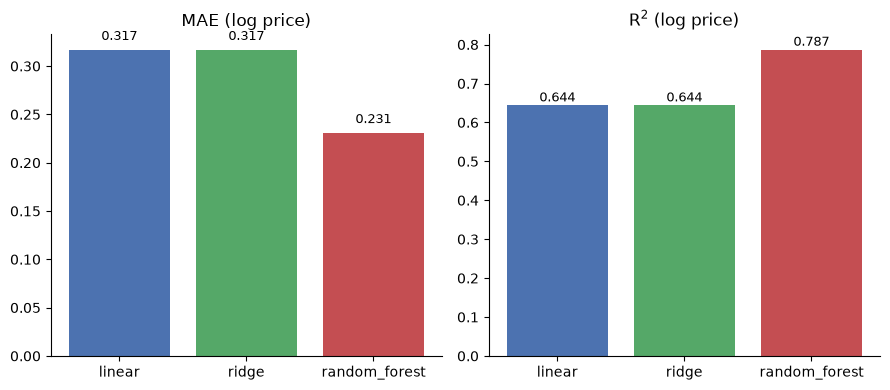

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
names = list(fitted)
axes[0].bar(names, [results.loc[k, "MAE (log)"] for k in names],
            color=["#4c72b0", "#55a868", "#c44e52"])
for i, k in enumerate(names):
    axes[0].text(i, results.loc[k, "MAE (log)"] + 0.01,
                 f"{results.loc[k, 'MAE (log)']:.3f}", ha="center", fontsize=9)
axes[0].set_title("MAE (log price)")
axes[1].bar(names, [results.loc[k, "R2 (log)"] for k in names],
            color=["#4c72b0", "#55a868", "#c44e52"])
for i, k in enumerate(names):
    axes[1].text(i, results.loc[k, "R2 (log)"] + 0.01,
                 f"{results.loc[k, 'R2 (log)']:.3f}", ha="center", fontsize=9)
axes[1].set_title("R$^2$ (log price)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


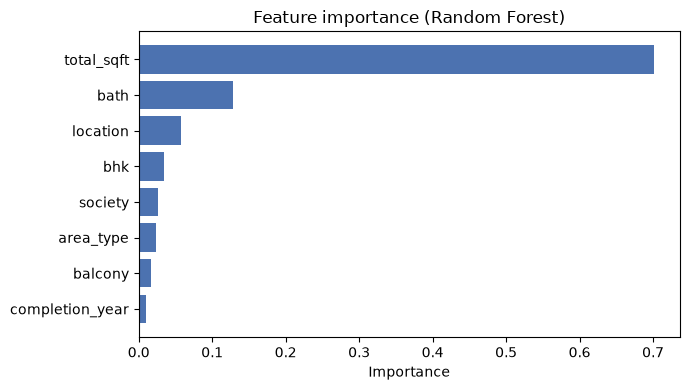

In [14]:

rf = fitted["random_forest"]
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(7, 4))
plt.barh(imp.index, imp.values, color="#4c72b0")
plt.title("Feature importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


Total area and BHK dominate - what a human would expect. Location frequency
captures how active a market is; society frequency adds a weak but real
signal.


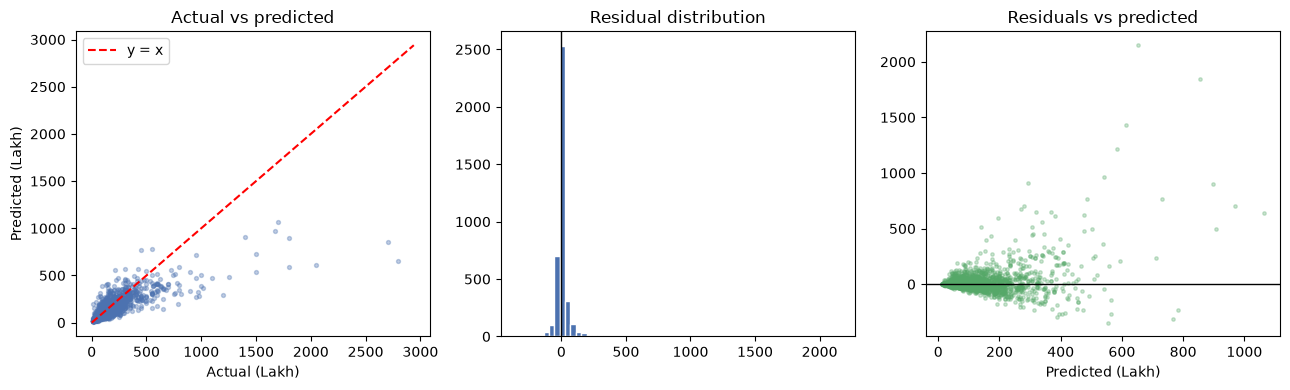

In [15]:

best_key = "random_forest"
X_best = X_test if best_key == "random_forest" else Xte_s
pred = np.expm1(fitted[best_key].predict(X_best))
resid = yte - pred

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(yte, pred, s=8, alpha=0.35, color="#4c72b0")
lims = [0, max(yte.max(), pred.max()) * 1.05]
axes[0].plot(lims, lims, "r--", lw=1.5, label="y = x")
axes[0].set_title("Actual vs predicted")
axes[0].set_xlabel("Actual (Lakh)")
axes[0].set_ylabel("Predicted (Lakh)")
axes[0].legend()
axes[1].hist(resid, bins=60, color="#4c72b0", edgecolor="white")
axes[1].axvline(0, color="k", lw=1)
axes[1].set_title("Residual distribution")
axes[2].scatter(pred, resid, s=6, alpha=0.3, color="#55a868")
axes[2].axhline(0, color="k", lw=1)
axes[2].set_title("Residuals vs predicted")
axes[2].set_xlabel("Predicted (Lakh)")
plt.tight_layout()
plt.show()


## 7. Save the artifacts used by the web app

In [16]:

os.makedirs(MODELS, exist_ok=True)
os.makedirs(ARTIFACTS, exist_ok=True)

joblib.dump(fitted["linear"], os.path.join(MODELS, "linear.joblib"), compress=3)
joblib.dump(fitted["ridge"], os.path.join(MODELS, "ridge.joblib"), compress=3)
joblib.dump(fitted["random_forest"], os.path.join(MODELS, "random_forest.joblib"), compress=3)

encoders = {
    "le_area_type": le_area,
    "location_freq": loc_freq,
    "society_freq": soc_freq,
    "feature_order": FEATURES,
    "scaler": scaler,
}
joblib.dump(encoders, os.path.join(MODELS, "encoders.joblib"), compress=3)

metrics = {
    "created": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "dataset": {
        "file": "data/Bengaluru_House_Data.csv",
        "source": "https://www.kaggle.com/amitabhajoy/bengaluru-house-price-data",
        "rows": len(data),
        "columns": len(data.columns),
    },
    "split": {
        "train": int(X_train.shape[0]),
        "test": int(X_test.shape[0]),
        "test_size": 0.3,
        "random_state": 2,
    },
    "target": "price (Lakh INR)",
    "target_transform": "log1p (predictions inverted before scoring)",
    "rows_dropped": int((~sane).sum()),
    "features": FEATURES,
    "models": {},
    "best_model": best_key,
}
names_map = {"linear": "Linear Regression", "ridge": "Ridge Regression",
             "random_forest": "Random Forest"}
for key in fitted:
    metrics["models"][key] = {
        "name": names_map[key],
        "params": ({"alpha": best_alpha} if key == "ridge"
                   else {"n_estimators": best_n_est, "min_samples_leaf": best_leaf} if key == "random_forest"
                   else {}),
        "test": {
            "r2_log": float(results.loc[key, "R2 (log)"]),
            "mae_log": float(results.loc[key, "MAE (log)"]),
            "mae": float(results.loc[key, "MAE (Lakh)"]),
            "rmse": float(results.loc[key, "RMSE (Lakh)"]),
        },
        "cv": {
            "mae_log_mean": round(float(results.loc[key, "CV MAE (log)"]), 3),
            "mae_log_std": round(float(cv_stds[key][0]), 3),
            "r2_log_mean": round(float(results.loc[key, "CV R2 (log)"]), 3),
            "r2_log_std": round(float(cv_stds[key][1]), 3),
        },
    }
with open(os.path.join(MODELS, "metrics.json"), "w", encoding="utf-8") as fh:
    json.dump(metrics, fh, indent=2)
print("saved models, encoders and metrics.json under", MODELS)


saved models, encoders and metrics.json under /home/user/HOUSE-PRICE-PREDICTION-USING-MACHINE-LEARNING-ALGORITHMS/models


## 8. Sample predictions

In [17]:

sample_idx = X_test.sample(3, random_state=7).index
sample = X_test.loc[sample_idx]

print("actual:", [round(v, 2) for v in yte.loc[sample_idx].tolist()])
for key in fitted:
    X_fit = X_test if key == "random_forest" else Xte_s
    p = np.expm1(fitted[key].predict(X_fit.loc[sample_idx]))
    print(f"{key:14s}", [round(v, 2) for v in p])
print()
print(sample[["total_sqft", "bath", "balcony", "bhk", "completion_year"]])


actual: [65.0, 245.0, 60.0]
linear         [np.float64(60.55), np.float64(285.18), np.float64(83.93)]
ridge          [np.float64(60.55), np.float64(285.18), np.float64(83.93)]
random_forest  [np.float64(53.53), np.float64(236.33), np.float64(72.47)]

      total_sqft  bath  balcony  bhk  completion_year
2079      1185.0   2.0      2.0    2                0
2306      3122.0   6.0      2.0    4                0
626       1400.0   3.0      2.0    3                0


## Takeaways

1. **Data quality dominates.** Unit conversion, dropping 0.4% impossible
   rows and handling missing society names matter more than the choice of
   algorithm.
2. **Random Forest is the best model** (R² log 0.787 test / 0.776 CV) -
   it captures the non-linear interactions between area, BHK and location
   that linear models miss.
3. **Log target + frequency encoding** are the two key design decisions:
   the log transform tames the price tail, and frequency encoding keeps
   thousands of categories in two small, meaningful features.
4. Predictions are estimates on a 2017-2020 snapshot and are not a
   substitute for a current market valuation.
